# 1. 图像的格式与读写

- 像素
    - 3-4字节构成
        - 3字节：R G B，BGR（YUV）：jpg，bmp，tiff, webp
        - 4字节：RGBA（Red， Green， Blue， Alpha）:通道（Channel）: png支持透明度
        - 每个自己存储一个颜色通道，其值0-255（无符号的整数）uint8， 浮点数数表示（计算过程使用：确保精度）
        - 在python：
            - 元组tuple：(255， 255， 255， 255)：透明度是通过运算体现。（支持0-255整数）
            - 小数（0.5, 0.3, 0.8, 1.0）:只能是0-1之间的效果。（matplotlib支持0-1小数）

- opencv，torch图像格式：
    - numpy.ndarray
        - (H, W, C)
    - torch.Tensor
        - (H, W, C)
- 3字节图像表示像素格式（伪彩色）
- 4字节（真彩色）

In [4]:
import  numpy
# 生成表达式构造图像
# 数据（python：生成表达式）
data = [[[255, 255, 0] for _ in range(50)] for _ in range(50)]
# 转换为numpy
img = numpy.array(data, dtype=numpy.uint8)   # 数组就是图像：
img.shape

(50, 50, 3)

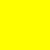

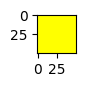

In [6]:
# 图像的显示3中
# 1. matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(0.5, 0.5))
plt.imshow(img)
# 2. opencv   # 基本上不使用
import cv2
cv2.imshow("window", img)
cv2.waitKey(3000)
cv2.destroyAllWindows()
# 3. PIL
import PIL
image = PIL.Image.fromarray(img)
image

# 2. 图像的特征

- 什么是特征：
    - 像素变化就是特征。
        - 像素变化的数学模型：一阶导数/一阶差分。
            - $f'(x) = \dfrac{f(x+\epsilon) - f(x - \epsilon)}{2\epsilon}$
            - $f'(x) = \dfrac{f(x+ 1) - f(x - 1)}{2}$  , 假设$\epsilon = 1$
            - $f'(x) = \dfrac{f(x+ 1) - f(x)}{1}$  , 假设$\epsilon = 1$

- 把导数使用代数表达式：
    - $f'(x) = \begin{bmatrix}  {1}&{-1} \end{bmatrix} \begin{bmatrix}  {f(x+1)}&\\ {f(x)} \end{bmatrix}$

- $f'(x) = \begin{bmatrix}  {1}&{0}&{-1} \\ {1}&{0}&{-1} \\ {1}&{0}&{-1} \end{bmatrix} \begin{bmatrix}  {f(x-1, y-1)}&{f(x, y-1)}&f(x+1, y-1) \\ {f(x-1, y)}&{f(x, y)} & f(x+1, y) \\ {f(x-1, y+1)}&{f(x, y+1)} & f(x+1, y+1)  \end{bmatrix}$

```python
cv.filter2D(
    src,       #被处理的图像
    ddepth,    # 保证处理后的图像也与原图保持一样的格式（使用uint8表示一个像素分量） -1
    kernel,    # 3 * 3的核
    dst,       # 使用参数作为输出（不使用）
    anchor,    # 锚点（-1） 表示中心对齐
    delta,     # 运算后，像素值很小，图像很黑，delta用来加载图像上  img + delta = 最终
    borderType # 补边（默认）
) 
```

```python
cv.Sobel(
    src,     # 原图像
    ddepth,   # 保持像素格式
    dx,      # 求导阶数 - x
    dy,      # 求导阶数 - y
    dst,    # 输出
    ksize,   # 核的大小
    scale,   # 缩放
    delta,   # 相位
    borderType) ->	dst
```

<function matplotlib.pyplot.show(close=None, block=None)>

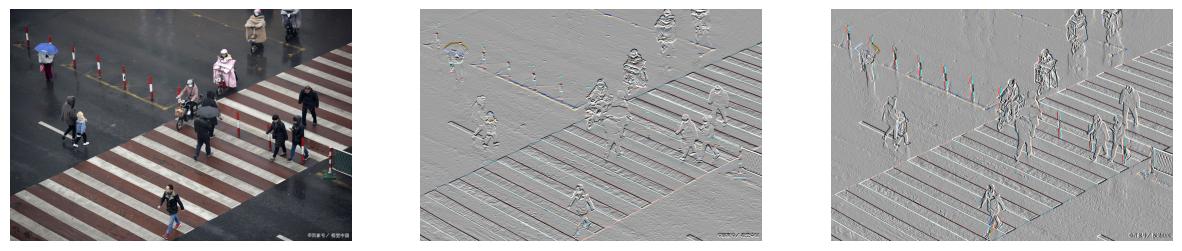

In [6]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
# 打开图像
img = cv2.imread("../../assets/images/04_traffic.jpg", cv2.IMREAD_COLOR_RGB)
# 准备核
kernel = np.array(    # 等价于sobel算子x=0, y=1 （很多其他模版）
    [
        [1,   1,   1],     # 下凹效果
        [0,   0,   0],
        [-1, -1,  -1]      # 为1 上凸
    ]
)

# 使用filter2D做卷积运算
feature_map_2d = cv2.filter2D(img, -1, kernel=kernel, delta=160)
feature_map_sobel = cv2.Sobel(img, -1, dx=1, dy=0, ksize=3, scale=1.0, delta=160)
# 可视化
plt. figure(figsize=(5*3,5*1))

plt.subplot(1,3,1)
plt.imshow(img)
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(feature_map_2d)
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(feature_map_sobel)
plt.axis("off")

plt.show

- 代码说明：
    - 最经典的卷积算子：Prewitt
    - 未来深度学习(视觉，transformer自注意力都是找这个卷积核)
        - `3 * 3`未来演化出`1*1`,`1*3`

# 3. pytorch的图像基础

- 经典的卷积神经网络：
    - LeNet-5: 手写字符识别第一名。
    - AlexNet：手写识别
    - GoogleNet
    - ResNet
    - EfficentNet
    - VGG：深层网络：网络深度可以无穷扩展
    - Inception V3：`1*3`的卷积核
    - VisionTransformer
    - 图像分类开始向目标侦测发展
        - 两阶段网络：网格，特征目标侦测
            - RNN
            - SSD
            - DeepLab
            - ... 
        - YOLO：一阶段的目标侦测
            - ....
    - 从分类->侦测->分隔->内容生成发展->多模态->意图理解。
        - 解码器（生成样本）
        - GAN